# Klasyfikacja symboli nutowych - wieloskalowe dopasowanie szablonu

## Dlaczego nie GeneralizedHoughGuil do klasyfikacji?

`GeneralizedHoughGuil` jest detektorem obiektow w **duzej scenie**: szuka wzorca wewnatrz
wiekszego obrazu, glosujac w przestrzeni (x, y, skala, kat). Gdy obraz zapytania ma **podobny
rozmiar co wzorzec** (izolowany symbol), akumulator nie dziala sensownie - algorytm nagradza
male skale, bo malutki template pasuje do wielu fragmentow obrazu.

## Wlasciwe podejscie: wieloskalowe `matchTemplate`

Dla kazdego wzorca i kazdej testowanej skali:
1. Przeskaluj zapytanie do rozmiaru wzorca x skala
2. Oblicz `cv2.matchTemplate(..., TM_CCOEFF_NORMED)` - wynik w [-1, 1]
3. Wez maksimum po wszystkich skalach i pozycjach

To jest **dokladnie** to co GHT mial robic, ale dzialajace poprawnie dla malych obrazow.

| Wlasciwosc | GHT (Guil) | Multi-scale matchTemplate |
|---|---|---|
| Skala | tak (zakres) | tak (siatka krokow) |
| Izolowane symbole | NIE akumulator nie dziala | TAK dziala |
| Interpretacja wyniku | glosy / edge_px | TM_CCOEFF_NORMED w [-1, 1] |
| Szybkosc | wolny (4D akumulator) | szybki |

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
import time
import pandas as pd

PATTERNS_DIR = Path('../classical_recognition/patterns_padded')

# Siatka skal do przeszukania
SCALE_RANGE = np.concatenate([
    np.arange(0.7, 1.4, 0.05),
])

print('cv2:', cv2.__version__)
print(f'Siatka skal: {len(SCALE_RANGE)} krokow, {SCALE_RANGE[0]:.2f}-{SCALE_RANGE[-1]:.2f}')
print('Katalog wzorow:', PATTERNS_DIR.resolve())

cv2: 4.13.0
Siatka skal: 14 krokow, 0.70-1.35
Katalog wzorow: D:\Pulpit\Studia\Semestr 6\GGSN\Projektowe\OMR-classic-vs-deep-comparison\classical_recognition\patterns_padded


## Ladowanie wzorow

In [56]:
@dataclass
class PatternTemplate:
    name: str
    template: np.ndarray    # uint8, biale na czarnym


def _to_white_on_black(gray: np.ndarray) -> np.ndarray:
    corners = [gray[0,0], gray[0,-1], gray[-1,0], gray[-1,-1]]
    bg = int(np.median(corners))
    return cv2.bitwise_not(gray) if bg > 127 else gray.copy()


def load_templates(patterns_dir: Path) -> list[PatternTemplate]:
    EXCLUDE = {'augmentation.png',
    'barline.png', 'barline_double.png',
    'barline_end.png', 'barline_repeat.png',
    'head2.png', 'head4.png', }
    templates = []
    for path in sorted(patterns_dir.glob('*.png')):
        if path.name in EXCLUDE:
            continue
        gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            print(f'  [WARN] nie mozna wczytac {path.name}')
            continue
        templates.append(PatternTemplate(
            name     = path.stem,
            template = _to_white_on_black(gray),
        ))
    print(f'Zaladowano {len(templates)} wzorow.')
    return templates


TEMPLATES = load_templates(PATTERNS_DIR)

Zaladowano 36 wzorow.


# Jako Mediana

note4: wzorzec z 50 przykładów
note8: wzorzec z 50 przykładów
note2: wzorzec z 50 przykładów
note1: wzorzec z 50 przykładów
note16: wzorzec z 50 przykładów


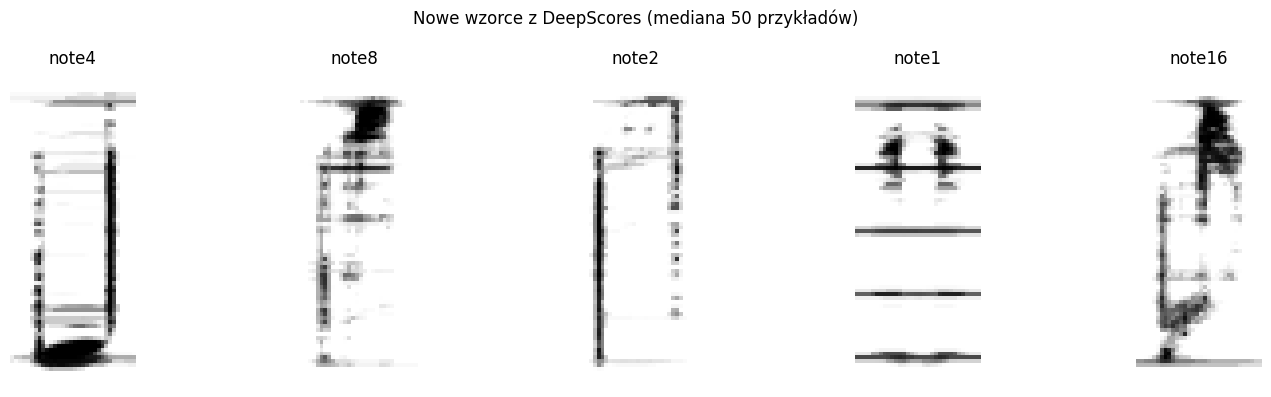

In [52]:
def normalize_to_symbol(img, target_size=(32, 80)):
    """Wytnij tight bbox białych pikseli, przeskaluj do stałego rozmiaru."""
    coords = cv2.findNonZero(img)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]
    return cv2.resize(cropped, target_size, interpolation=cv2.INTER_AREA)

def build_median_template(image_paths, target_size=(32, 80)):
    resized = []
    for p in image_paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        norm = normalize_to_symbol(img, target_size)
        if norm is not None:
            resized.append(norm.astype(np.float32))
    if not resized: return None
    return np.median(resized, axis=0).astype(np.uint8)


# Wczytaj labels
df = pd.read_csv('../data/note_dataset/notes/labels.csv')
img_dir = Path('../data/note_dataset/notes/images')

# Buduj wzorzec per klasa z pierwszych 50 przykładów
TEMPLATES = {}
for note_type in df['note_type'].unique():
    paths = [img_dir / row['id']
             for _, row in df[df['note_type'] == note_type].head(50).iterrows()]
    tpl = build_median_template(paths)
    if tpl is not None:
        TEMPLATES[note_type] = tpl
        print(f'{note_type}: wzorzec z {len(paths)} przykładów')

# Wyświetl nowe wzorce
fig, axes = plt.subplots(1, len(TEMPLATES), figsize=(len(TEMPLATES)*3, 4))
for ax, (name, tpl) in zip(axes, TEMPLATES.items()):
    ax.imshow(tpl, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle('Nowe wzorce z DeepScores (mediana 50 przykładów)')
plt.tight_layout()
plt.show()

Counter({'note4': 200, 'note8': 200, 'note2': 200, 'note1': 200, 'note16': 200})


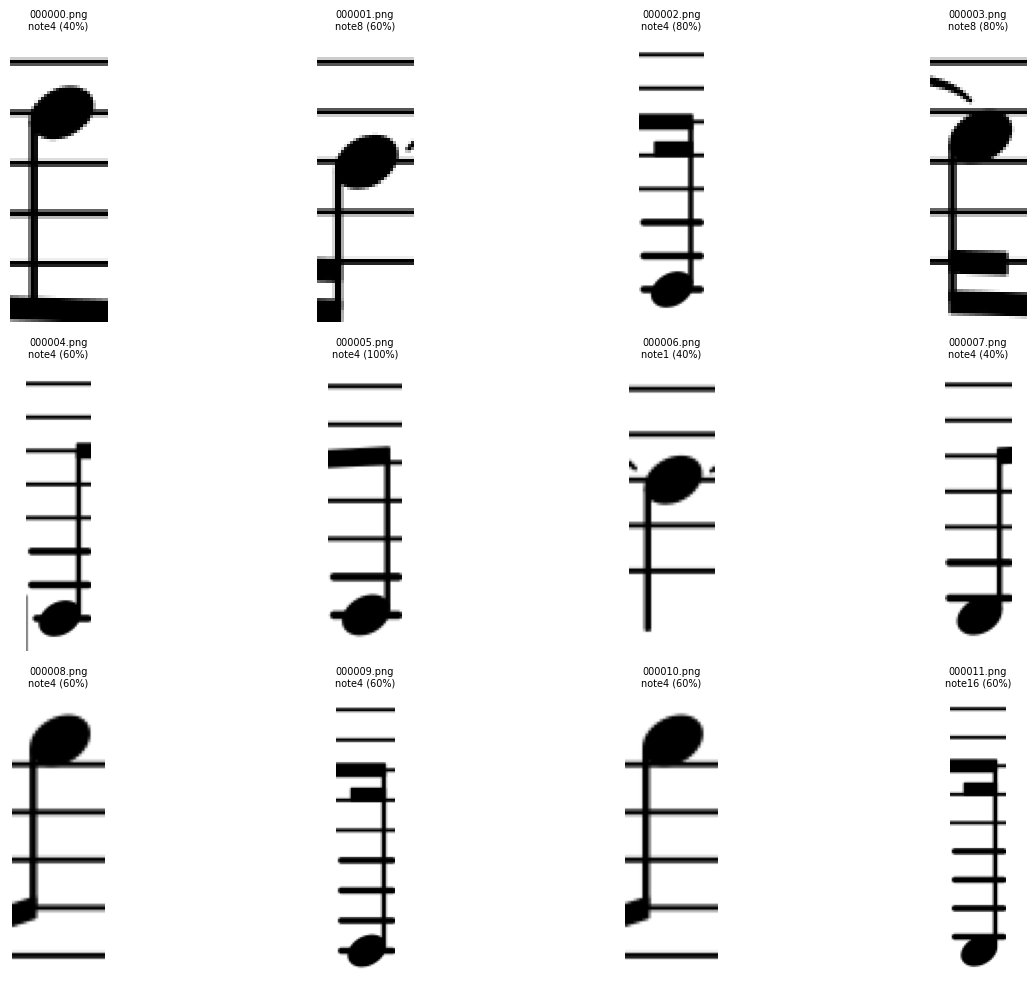

In [55]:
def hu_moments(img, remove_lines=True):
    if remove_lines:
        img = remove_staff_lines(img)  # Twoja funkcja z fill_thresh=0.80
    coords = cv2.findNonZero(img)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]
    m = cv2.moments(cropped)
    hu = cv2.HuMoments(m).flatten()
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)


# Zbuduj bazę danych momentów ze zbioru treningowego
import pandas as pd
from pathlib import Path

df      = pd.read_csv('../data/note_dataset/notes/labels.csv')
img_dir = Path('../data/note_dataset/notes/images')
N_PER_CLASS = 200
db_moments = []
for note_type in df['note_type'].unique():
    subset = df[df['note_type'] == note_type].sample(
        min(N_PER_CLASS, len(df[df['note_type'] == note_type])),
        random_state=42
    )
    for _, row in subset.iterrows():
        img = cv2.imread(str(img_dir / row['id']), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        hu = hu_moments(img)
        if hu is not None:
            db_moments.append((hu, note_type))

from collections import Counter
print(Counter(lbl for _, lbl in db_moments))


# Klasyfikacja przez k-NN (k=5) na momentach
def classify_by_hu(query_img, db_moments, k=5):
    """Klasyfikuj przez k-NN na momentach Hu."""
    q_hu = hu_moments(query_img)
    if q_hu is None:
        return None, 0.0

    dists = [(np.linalg.norm(q_hu - m), lbl) for m, lbl in db_moments]
    dists.sort(key=lambda x: x[0])

    # Głosowanie k najbliższych
    from collections import Counter
    votes = Counter(lbl for _, lbl in dists[:k])
    best_label, best_count = votes.most_common(1)[0]
    confidence = best_count / k
    return best_label, confidence


# Test na kilku obrazach
test_paths = sorted(Path('../data/note_dataset/notes/images').glob('*.png'))[:12]
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, path in zip(axes.flatten(), test_paths):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    label, conf = classify_by_hu(img, db_moments)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{path.name}\n{label} ({conf:.0%})', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Glowna funkcja klasyfikacji `classify_symbol()`

In [40]:
from dataclasses import dataclass as _dc

@_dc
class ClassifyResult:
    label:       str
    score:       float    # TM_CCOEFF_NORMED w [-1, 1]; im wyzszy tym lepszy
    best_scale:  float    # skala przy ktorej znaleziono najlepsze dopasowanie
    ranking:     list     # lista (label, score, scale) top_k najlepszych


def _match_score(query_gray: np.ndarray,
                 template: np.ndarray,
                 scales: np.ndarray) -> tuple[float, float]:
    h_t, w_t = template.shape
    best_score, best_scale = -1.0, 1.0

    for s in scales:
        qh = max(1, int(query_gray.shape[0] * s))
        qw = max(1, int(query_gray.shape[1] * s))
        q_resized = cv2.resize(query_gray, (qw, qh), interpolation=cv2.INTER_LINEAR)

        if qh >= h_t and qw >= w_t:
            img, tmpl = q_resized, template
        elif qh > 0 and qw > 0:
            tmpl = cv2.resize(template, (qw, qh), interpolation=cv2.INTER_LINEAR)
            img  = q_resized
        else:
            continue

        res   = cv2.matchTemplate(img, tmpl, cv2.TM_CCOEFF_NORMED)
        score = float(res.max())
        if score > best_score:
            best_score, best_scale = score, s

    return best_score, best_scale


def classify_symbol(
    img_white_on_black: np.ndarray,
    templates: list[PatternTemplate] = TEMPLATES,
    scales: np.ndarray = SCALE_RANGE,
    top_k: int = 5,
    verbose: bool = False,
) -> ClassifyResult:
    """
    Klasyfikuje symbol nutowy metoda wieloskalowego matchTemplate.

    Parametry
    ----------
    img_white_on_black : np.ndarray
        Obraz wejsciowy (uint8, szarosc lub BGR).
        Konwencja: biale symbole na czarnym tle.
        Rozmiar moze byc dowolny - algorytm przeszukuje siatke skal.
    templates : list[PatternTemplate]
        Lista wzorow (domyslnie globalna TEMPLATES).
    scales : np.ndarray
        Siatka mnoznikow skali do przeszukania.
    top_k : int
        Ile najlepszych wynikow zwrocic w rankingu.
    verbose : bool
        Drukuje wyniki dla kazdego wzorca.

    Zwraca
    -------
    ClassifyResult z:
        - label      - nazwa klasy
        - score      - TM_CCOEFF_NORMED w [-1, 1]
        - best_scale - skala przy ktorej znaleziono dopasowanie
        - ranking    - lista (label, score, scale) top_k najlepszych
    """
    if img_white_on_black.ndim == 3:
        query = cv2.cvtColor(img_white_on_black, cv2.COLOR_BGR2GRAY)
    else:
        query = img_white_on_black.copy()

    results = []
    t0 = time.perf_counter()

    for pt in templates:
        score, scale = _match_score(query, pt.template, scales)
        results.append((pt.name, score, scale))
        if verbose:
            print(f'  {pt.name:<20s}  score={score:6.3f}  scale={scale:.2f}')

    elapsed = time.perf_counter() - t0
    if verbose:
        print(f'Czas: {elapsed*1000:.1f} ms')

    results.sort(key=lambda r: r[1], reverse=True)
    ranking = [(name, score, scale) for name, score, scale in results[:top_k]]
    best = results[0]

    return ClassifyResult(
        label      = best[0],
        score      = best[1],
        best_scale = best[2],
        ranking    = ranking,
    )

print('classify_symbol() gotowa.')

classify_symbol() gotowa.


## Test na wzorcach (self-test)

Kazdy wzorzec testujemy na sobie - oczekujemy score bliskiego 1.0 i skali ~1.0.

In [41]:
pattern_map = {pt.name: pt for pt in TEMPLATES}

print(f'{"Wzorzec":<22s}  {"Top-1":<22s}  {"score":>6s}  {"skala":>6s}  OK?')
print('-' * 68)

correct = 0
for pt in TEMPLATES:
    result = classify_symbol(pt.template)
    ok = result.label == pt.name
    correct += int(ok)
    mark = 'OK' if ok else f'FAIL -> {result.label}'
    print(f'{pt.name:<22s}  {result.label:<22s}  {result.score:6.3f}  {result.best_scale:6.2f}  {mark}')

print(f'\nSelf-test: {correct}/{len(TEMPLATES)} poprawnych')

Wzorzec                 Top-1                    score   skala  OK?
--------------------------------------------------------------------
12_8                    12_8                     1.000    0.70  OK
2_2                     2_2                      1.000    0.70  OK
3_2                     3_2                      1.000    0.70  OK
3_4                     3_4                      1.000    0.70  OK
3_8                     3_8                      1.000    0.70  OK
4_4                     4_4                      1.000    0.85  OK
5_4                     5_4                      1.000    0.70  OK
5_8                     5_8                      1.000    1.00  OK
6_4                     6_4                      1.000    0.70  OK
6_8                     6_8                      1.000    0.70  OK
7_8                     7_8                      1.000    0.75  OK
9_8                     9_8                      1.000    0.70  OK
bemol                   bemol                    1.000    0

## Test odpornosci na zmiane skali

Skalujemy wzorzec (0.5x, 0.75x, 1.5x, 2.0x) i sprawdzamy, czy klasyfikacja pozostaje prawidlowa.

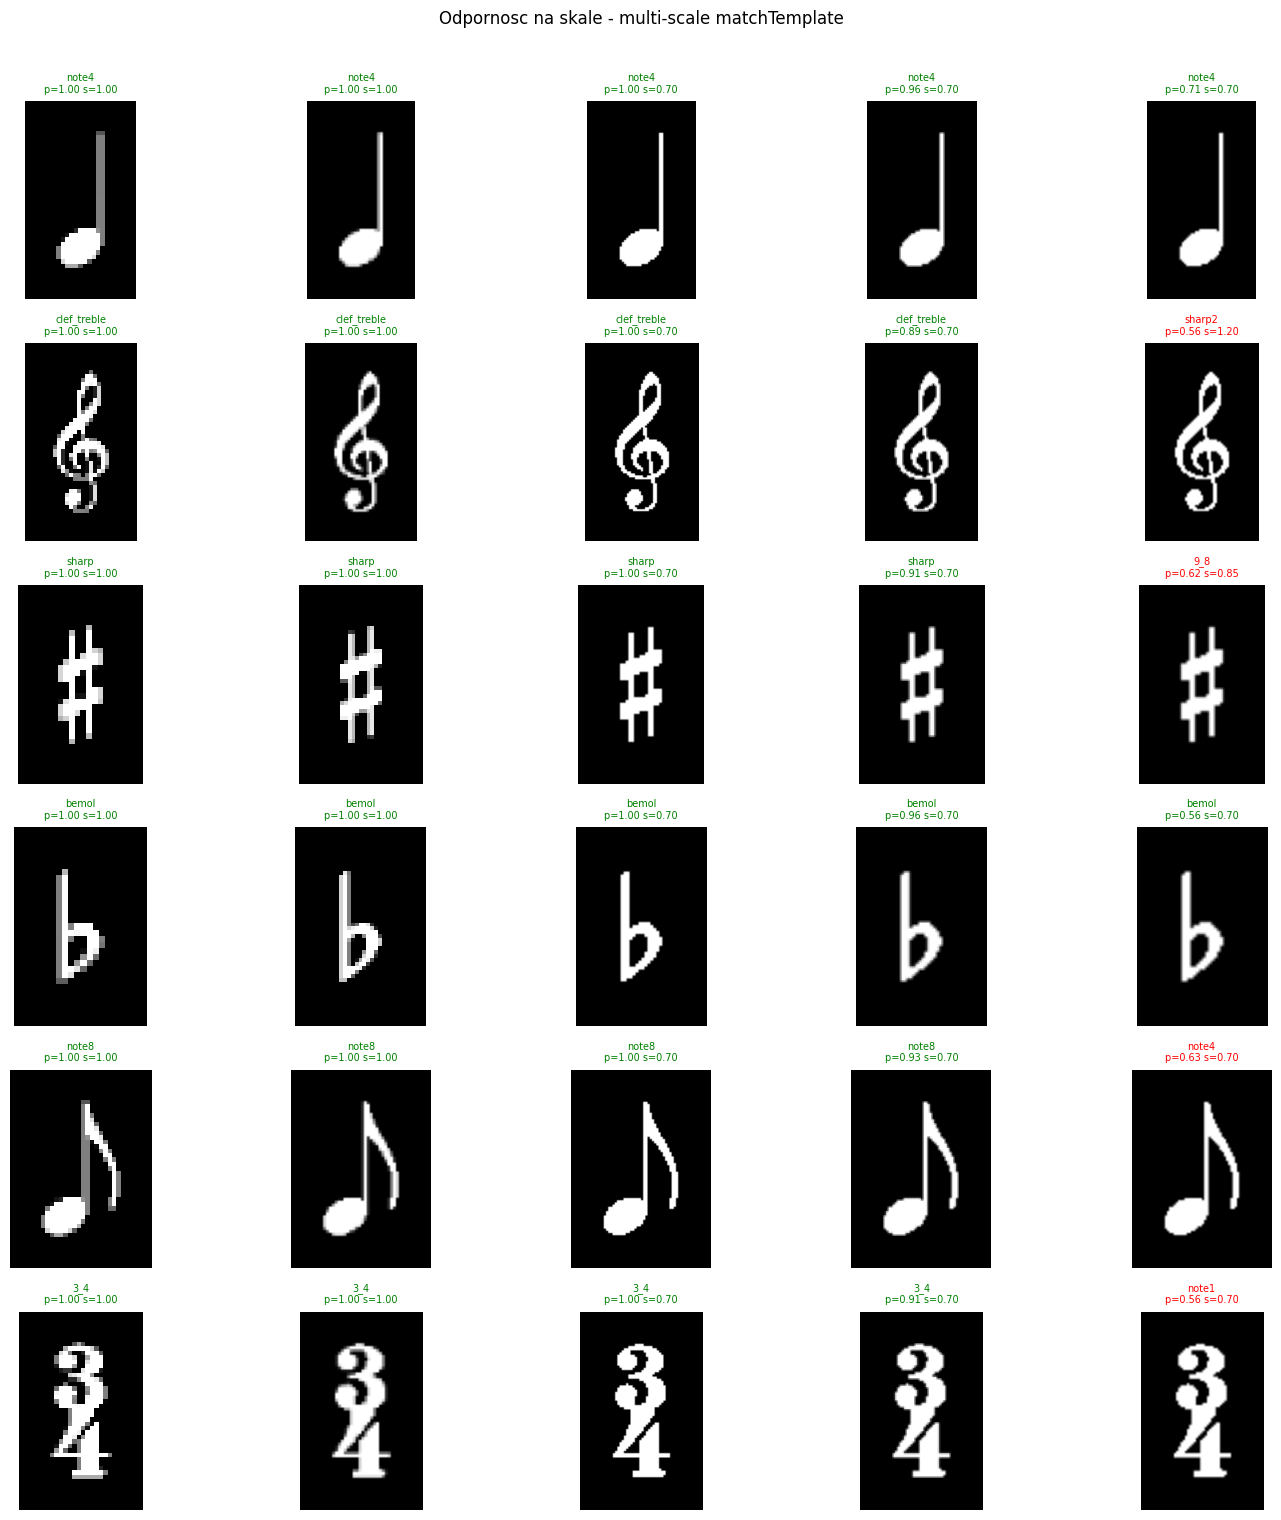

In [42]:
TEST_PATTERNS = ['note4', 'clef_treble', 'sharp', 'bemol', 'note8', '3_4']
SCALES_TEST   = [0.5, 0.75, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(len(TEST_PATTERNS), len(SCALES_TEST),
                          figsize=(len(SCALES_TEST)*3, len(TEST_PATTERNS)*2.5))

for row, pname in enumerate(TEST_PATTERNS):
    if pname not in pattern_map:
        print(f'[WARN] wzorzec {pname!r} nie istnieje'); continue
    tpl = pattern_map[pname].template

    for col, s in enumerate(SCALES_TEST):
        ax = axes[row, col]
        h, w = tpl.shape
        scaled = cv2.resize(tpl, (max(1,int(w*s)), max(1,int(h*s))), interpolation=cv2.INTER_LINEAR)

        result = classify_symbol(scaled)
        ok     = result.label == pname
        color  = 'green' if ok else 'red'

        ax.imshow(scaled, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{result.label}\np={result.score:.2f} s={result.best_scale:.2f}',
                     fontsize=7, color=color)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(pname, fontsize=8, rotation=0, labelpad=55, va='center')

plt.suptitle('Odpornosc na skale - multi-scale matchTemplate', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Test na obrazach z `data/note_dataset/notes/images`

In [43]:
def threshold_img(img, threshold_value, Otsu=False):
    _, img_bin = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY_INV)
    if Otsu:
        _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        _, img_bin = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY_INV)
    return img_bin

In [53]:
# def remove_staff_lines(img_white_on_black, scale=2, fill_thresh=0.80):
#     h, w = img_white_on_black.shape

#     # 1. Powiększ 2x dla lepszej łączności pionowej
#     big = cv2.resize(img_white_on_black, (w * scale, h * scale),
#                      interpolation=cv2.INTER_CUBIC)
#     _, binary = cv2.threshold(big, 127, 255, cv2.THRESH_BINARY)
#     H, W = binary.shape

#     # 2. Projection profile — tylko wiersze z fill >= 0.80 to linie
#     profile = binary.sum(axis=1) / (W * 255)
#     line_rows = set()
#     for y, fill in enumerate(profile):
#         if fill >= fill_thresh:
#             for d in range(-scale, scale + 1):
#                 if 0 <= y + d < H:
#                     line_rows.add(y + d)

#     # 3. Łączność pionowa — usuń TYLKO piksele bez sąsiadów poza liniami
#     result = binary.copy()
#     search = scale * 3
#     for y in sorted(line_rows):
#         for x in range(W):
#             if binary[y, x] == 0:
#                 continue
#             has_symbol = any(
#                 binary[y2, x] > 0
#                 for r in range(1, search + 1)
#                 for y2 in [y - r, y + r]
#                 if 0 <= y2 < H and y2 not in line_rows
#             )
#             if not has_symbol:
#                 result[y, x] = 0

#     # 4. Wróć do oryginalnego rozmiaru
#     return cv2.resize(result, (w, h), interpolation=cv2.INTER_AREA)

def remove_staff_lines(img_white_on_black, scale=2, fill_thresh=0.80):
    h, w = img_white_on_black.shape

    big = cv2.resize(img_white_on_black, (w * scale, h * scale),
                     interpolation=cv2.INTER_CUBIC)
    _, binary = cv2.threshold(big, 127, 255, cv2.THRESH_BINARY)
    H, W = binary.shape

    profile = binary.sum(axis=1) / (W * 255)
    line_rows = set()
    for y, fill in enumerate(profile):
        if fill >= fill_thresh:
            for d in range(-scale, scale + 1):
                if 0 <= y + d < H:
                    line_rows.add(y + d)

    result = binary.copy()
    search = scale * 4  # ← zwiększone z 3 do 4 (szuka dalej sąsiadów nuty)
    for y in sorted(line_rows):
        for x in range(W):
            if binary[y, x] == 0:
                continue
            has_symbol = any(
                binary[y2, x] > 0
                for r in range(1, search + 1)
                for y2 in [y - r, y + r]
                if 0 <= y2 < H and y2 not in line_rows
            )
            if not has_symbol:
                result[y, x] = 0

    # ── Nowość 1: usuń izolowane małe fragmenty (pozostałości linii) ──────────
    # Komponenty spójne mniejsze niż min_area pikseli → usuń jako szum
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(result)
    min_area = scale * scale * 4   # przy scale=2: min 16px
    clean = np.zeros_like(result)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == lbl] = 255

    # ── Nowość 2: napraw stem — pionowe zamknięcie morfologiczne ──────────────
    # Skleja ewentualne przerwy w ogonku nuty powstałe po usunięciu linii
    kh = max(3, scale * 2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kh))
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

    return cv2.resize(clean, (w, h), interpolation=cv2.INTER_AREA)

30


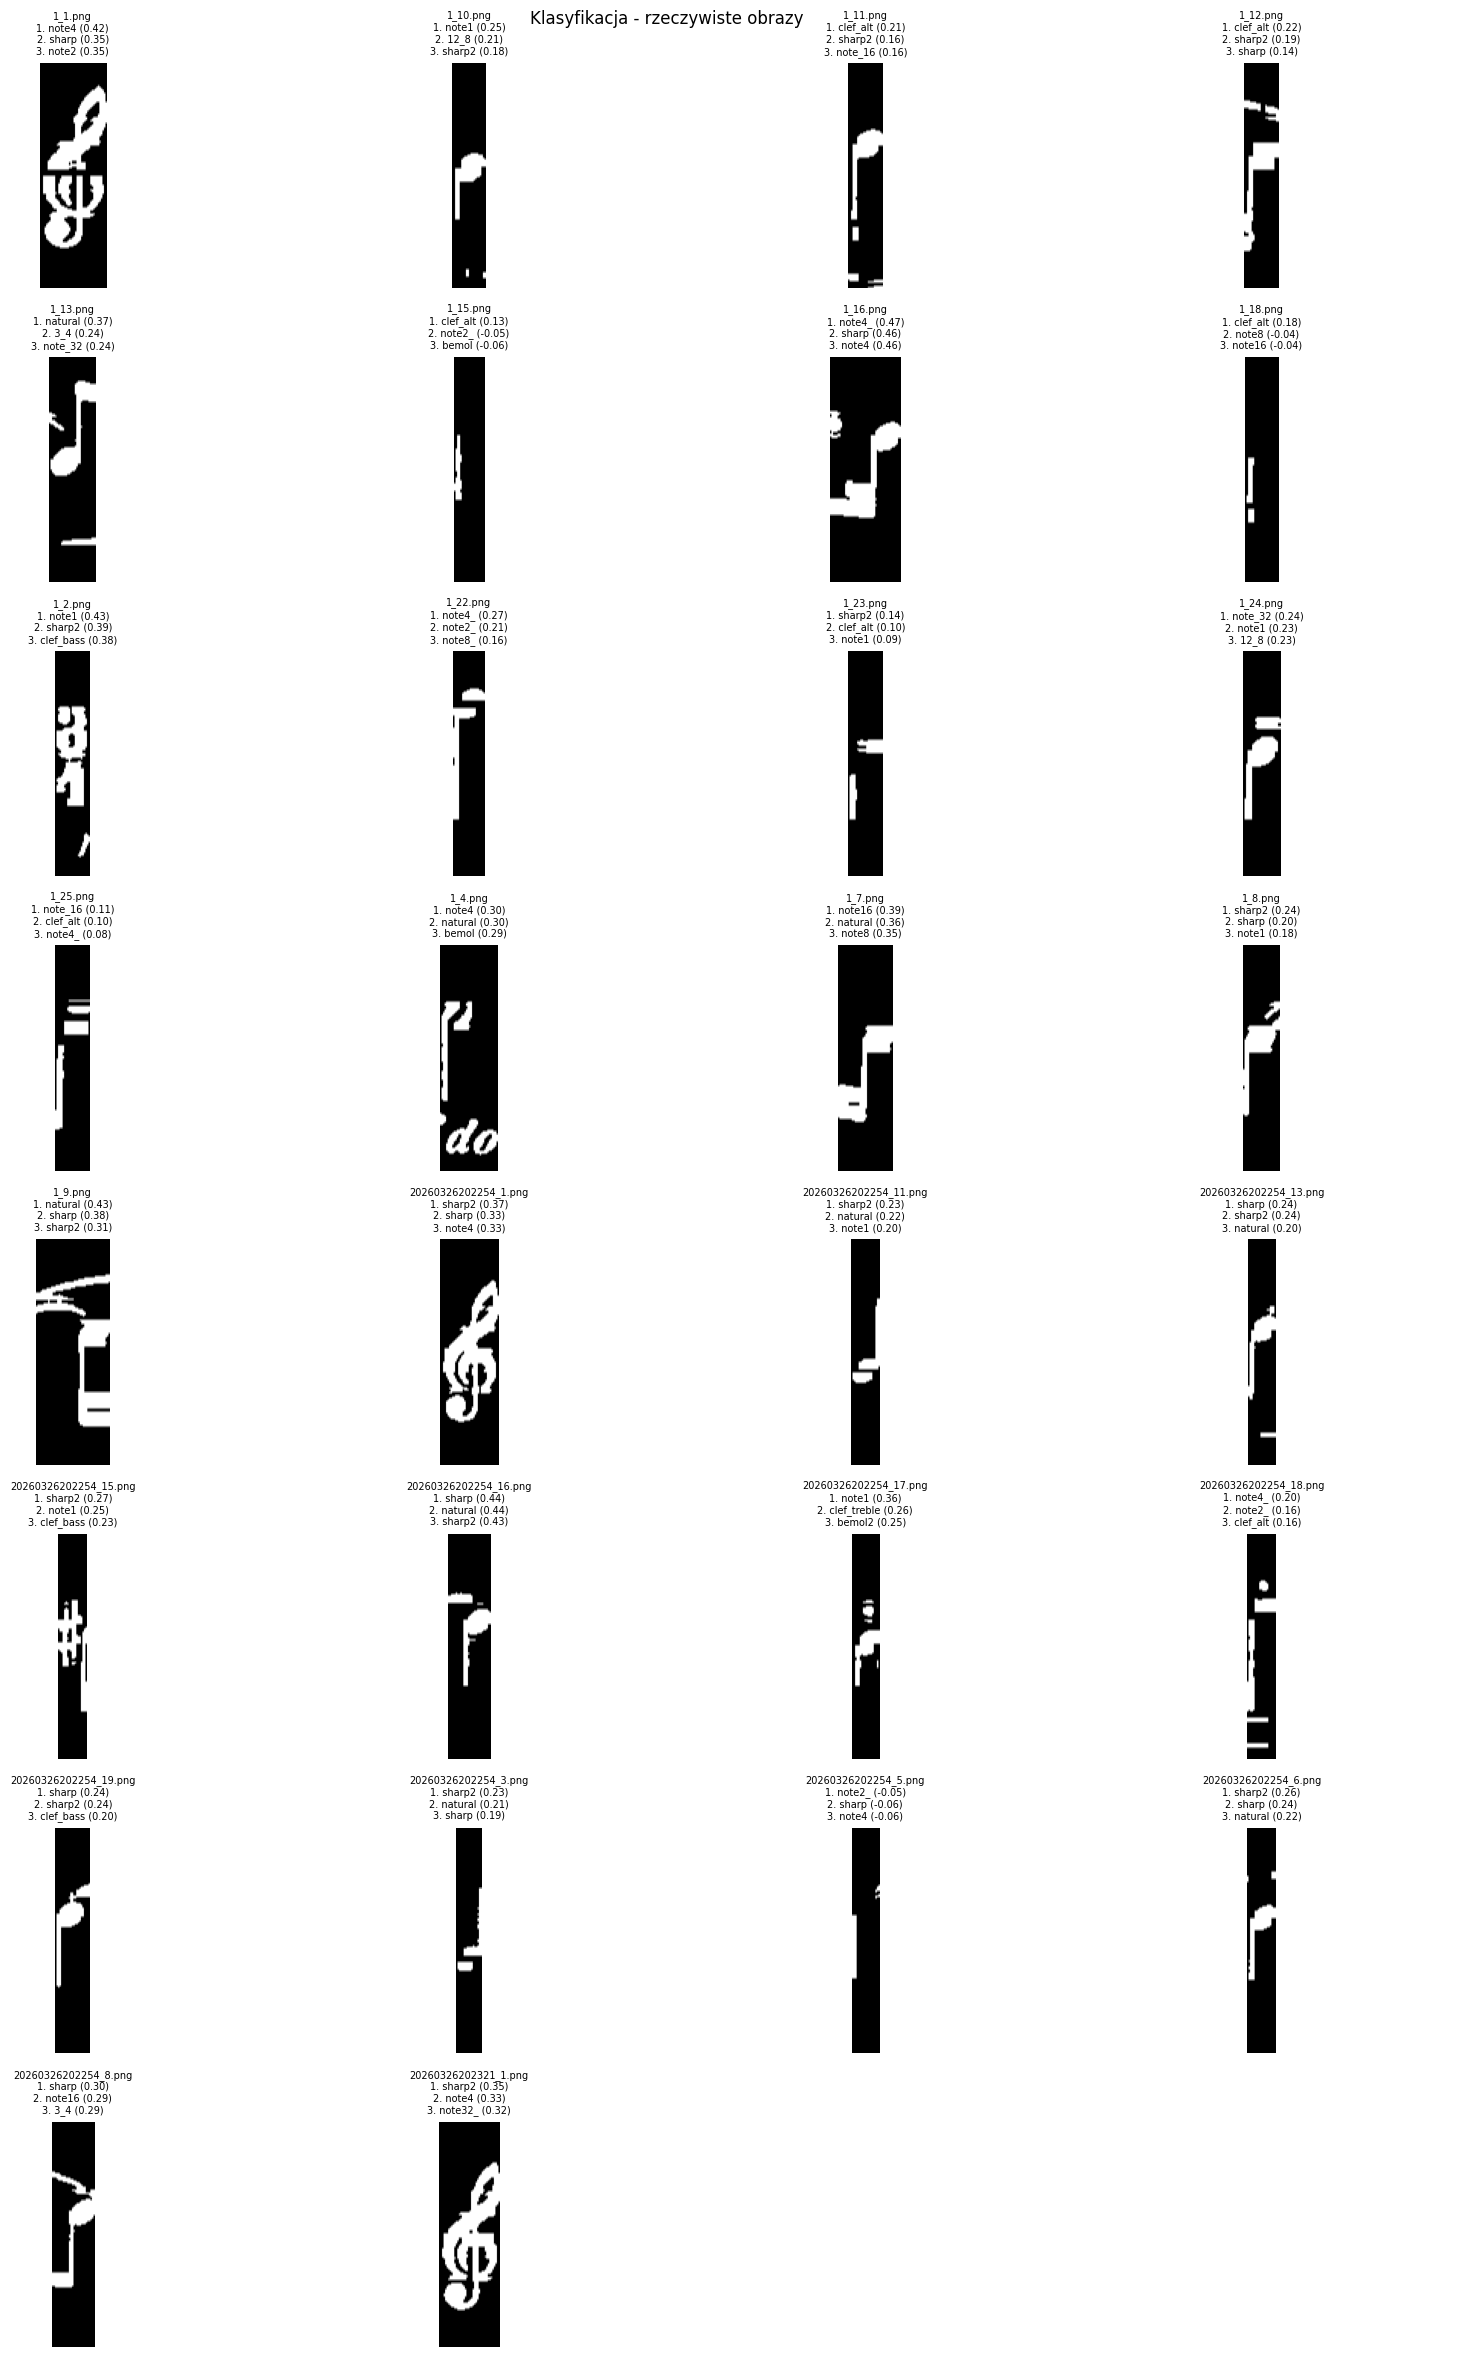

In [60]:
DATA_DIR   = Path('../data/note_pitches_selected')
SAMPLE_N   = 30

sample_paths = sorted(DATA_DIR.glob('*.png'))[:SAMPLE_N]
print(len(sample_paths))
cols = 4
rows = (len(sample_paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()

for ax, path in zip(axes, sample_paths):
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    gray = threshold_img(gray, 200, Otsu=False)
    gray = remove_staff_lines(gray)
    if gray is None: ax.axis('off'); continue
    query = _to_white_on_black(gray)
    result = classify_symbol(query)
    ax.imshow(query, cmap='gray', vmin=0, vmax=255)
    ranking_str = '\n'.join(
        f'{i+1}. {lbl} ({s:.2f})' for i,(lbl,s,_) in enumerate(result.ranking[:3])
    )
    ax.set_title(f'{path.name}\n{ranking_str}', fontsize=7)
    ax.axis('off')

for ax in axes[len(sample_paths):]:
    ax.axis('off')
plt.suptitle('Klasyfikacja - rzeczywiste obrazy', fontsize=12)
plt.tight_layout()
plt.show()

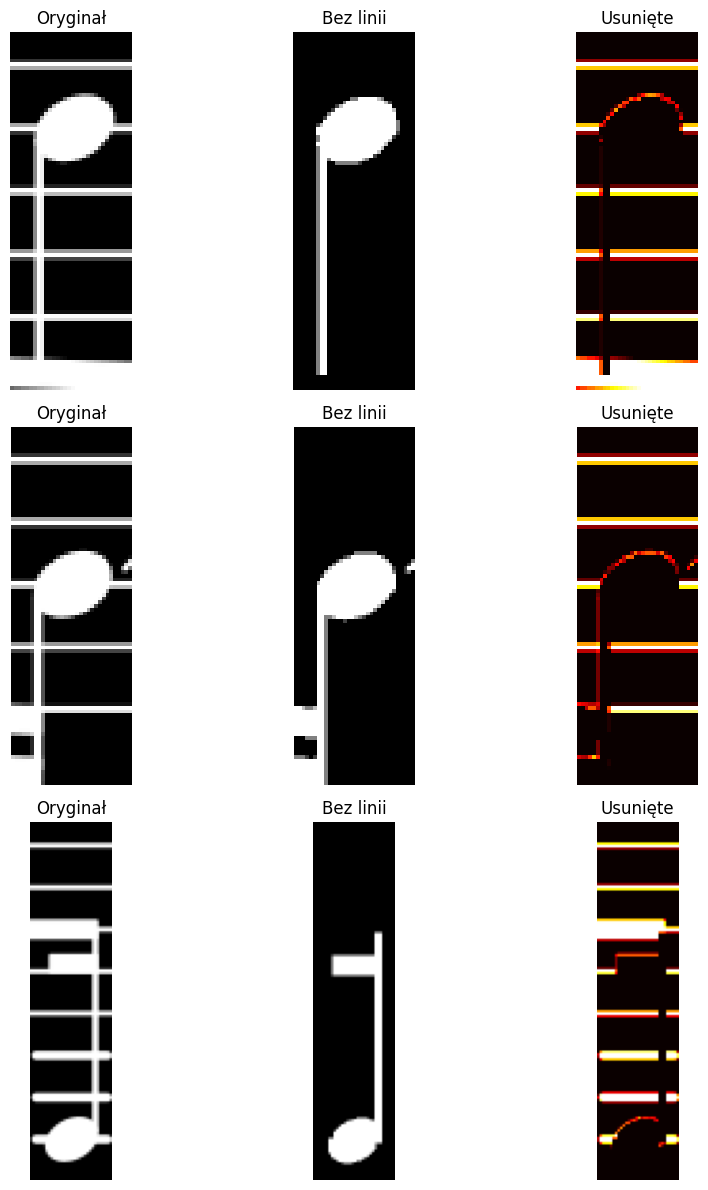

In [46]:
fig, axes = plt.subplots(3, 3, figsize=(10, 12))
for row, path in enumerate(sorted(DATA_DIR.glob('*.png'))[:3]):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    corners = [img[0,0], img[0,-1], img[-1,0], img[-1,-1]]
    if int(np.median(corners)) > 127:
        img = cv2.bitwise_not(img)

    cleaned = remove_staff_lines(img)

    axes[row, 0].imshow(img,     cmap='gray'); axes[row, 0].set_title('Oryginał');  axes[row, 0].axis('off')
    axes[row, 1].imshow(cleaned, cmap='gray'); axes[row, 1].set_title('Bez linii'); axes[row, 1].axis('off')

    # Diff — co zostało usunięte
    diff = cv2.subtract(img, cleaned)
    axes[row, 2].imshow(diff, cmap='hot');   axes[row, 2].set_title('Usunięte');  axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

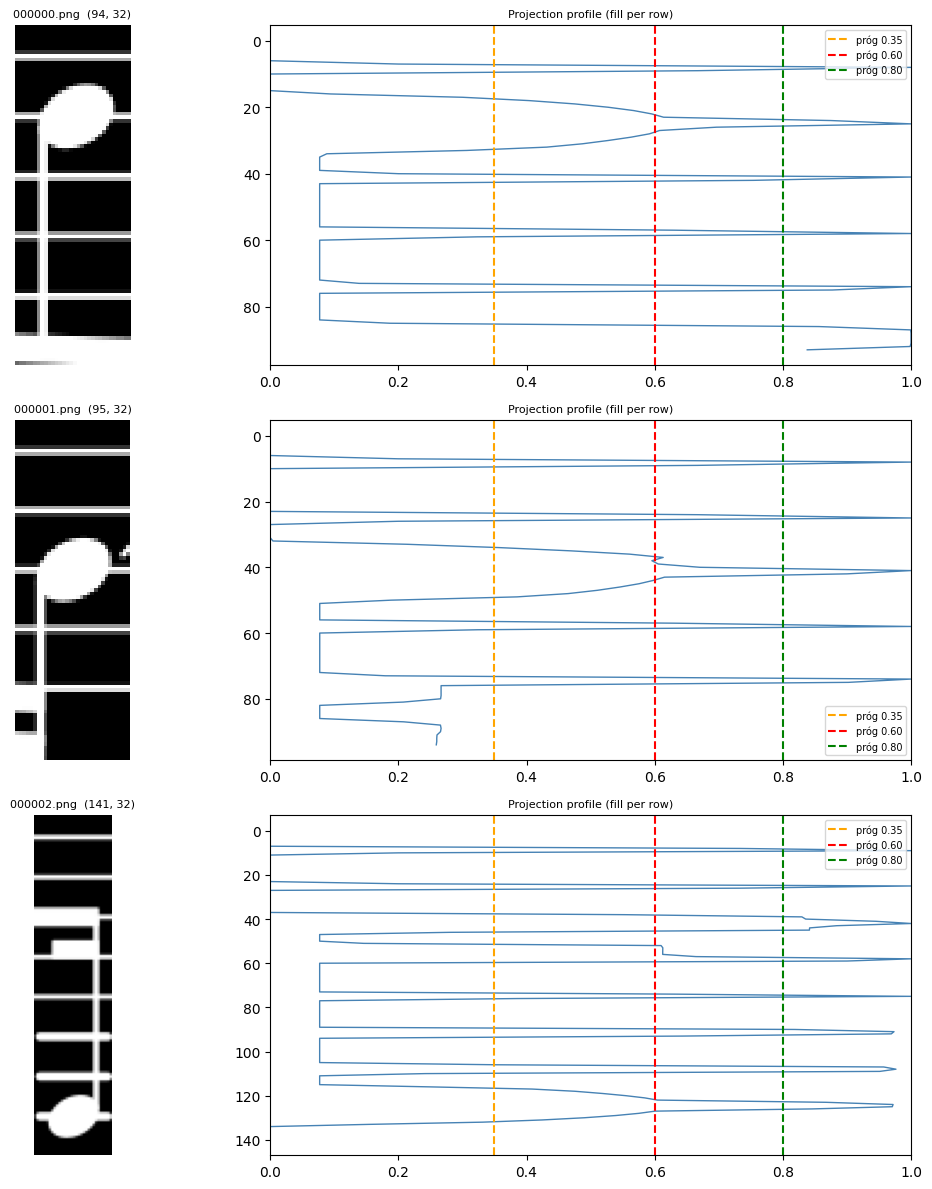

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data/note_dataset/notes/images')
paths = sorted(DATA_DIR.glob('*.png'))[:3]

fig, axes = plt.subplots(len(paths), 2, figsize=(12, len(paths)*4))

for row, path in enumerate(paths):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    # Zapewnij białe symbole na czarnym tle
    corners = [img[0,0], img[0,-1], img[-1,0], img[-1,-1]]
    if int(np.median(corners)) > 127:
        img = cv2.bitwise_not(img)

    H, W = img.shape
    profile = img.sum(axis=1) / (W * 255)

    # Lewo: obraz
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{path.name}  {img.shape}', fontsize=8)
    axes[row, 0].axis('off')

    # Prawo: projection profile
    axes[row, 1].plot(profile, np.arange(H), color='steelblue', lw=1)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].axvline(0.35, color='orange', ls='--', label='próg 0.35')
    axes[row, 1].axvline(0.60, color='red',    ls='--', label='próg 0.60')
    axes[row, 1].axvline(0.80, color='green',  ls='--', label='próg 0.80')
    axes[row, 1].legend(fontsize=7)
    axes[row, 1].set_title('Projection profile (fill per row)', fontsize=8)

plt.tight_layout()
plt.show()

## Wizualizacja rankingu dla pojedynczego obrazu

  12_8                  score= 0.144  scale=0.70
  2_2                   score= 0.105  scale=0.70
  3_2                   score= 0.065  scale=0.70
  3_4                   score= 0.046  scale=0.70
  3_8                   score= 0.050  scale=0.95
  4_4                   score= 0.030  scale=0.70
  5_4                   score= 0.019  scale=0.70
  5_8                   score= 0.015  scale=0.70
  6_4                   score= 0.079  scale=0.85
  6_8                   score= 0.084  scale=0.70
  7_8                   score= 0.075  scale=0.95
  9_8                   score= 0.098  scale=1.20
  bemol                 score=-0.067  scale=0.75
  bemol2                score=-0.039  scale=0.95
  clef_alt              score= 0.127  scale=0.75
  clef_bass             score= 0.148  scale=1.10
  clef_treble           score= 0.003  scale=0.75
  natural               score= 0.336  scale=1.35
  note1                 score=-0.056  scale=0.90
  note16                score= 0.016  scale=1.00
  note16_           

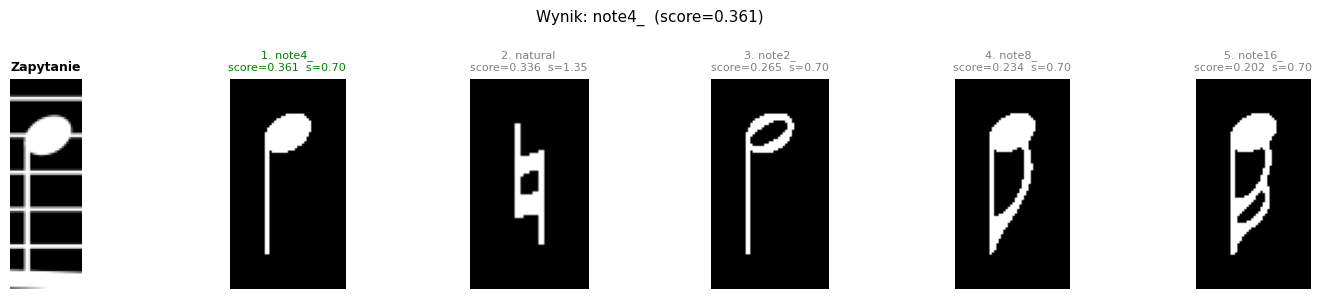

In [48]:
def show_classification(img_white_on_black: np.ndarray, top_k: int = 5):
    result = classify_symbol(img_white_on_black, top_k=top_k, verbose=True)

    fig, axes = plt.subplots(1, top_k + 1, figsize=((top_k+1)*2.5, 3))
    axes[0].imshow(img_white_on_black, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Zapytanie', fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for i, (lbl, score, scale) in enumerate(result.ranking):
        ax = axes[i+1]
        if lbl in pattern_map:
            ax.imshow(pattern_map[lbl].template, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{i+1}. {lbl}\nscore={score:.3f}  s={scale:.2f}',
                     fontsize=8, color='green' if i == 0 else 'gray')
        ax.axis('off')

    plt.suptitle(f'Wynik: {result.label}  (score={result.score:.3f})', fontsize=11)
    plt.tight_layout()
    plt.show()


first_img_path = sorted(DATA_DIR.glob('*.png'))[0]
first_img = _to_white_on_black(cv2.imread(str(first_img_path), cv2.IMREAD_GRAYSCALE))
show_classification(first_img)